In [1]:
import os
import sys
import numpy as np
import torch
from matplotlib.collections import PolyCollection

sys.path.append('/ifshome/abenneck/docs_public/yolo_model/docs/scripts')
import yolo_post_help
from yolo_post_help import remove_low_conf_bboxes, postprocess, bb_to_rec

# 2D Example

In [2]:
def stardist_to_bbox(raw_output, mode='2D'):
    """
    Converts a standard output from the 2D StarDist model to a set of bounding boxes
    """

    bb_out = []
    if mode == '2D':
        for i in range(len(raw_output['coord'])):
            coords = raw_output['coord'][i]
            center = raw_output['points'][i]
            prob = float(raw_output['prob'][i])
    
            xmin = float(min(coords[1]))
            xmax = float(max(coords[1]))
            ymin = float(min(coords[0]))
            ymax = float(max(coords[0]))
    
            bb_out.append([xmin, xmax, ymin, ymax, prob])
    elif mode == '3D':
        n_ray = raw_outputs['dist'].shape[1]
        n_cells = raw_outputs['dist'].shape[0]
        n_dim = raw_outputs['points'].shape[1]
        for i in range(n_cells):
            prob = raw_outputs['prob'][i]
            center = raw_outputs['points'][i]
            n_vectors = [raw_outputs['rays_vertices'][j]*raw_outputs['dist'][i][j] for j in range(n_ray)]
            n_vectors = np.asarray(n_vectors) + center
        
            xmin, ymin, zmin = np.min(n_vectors, axis=0)
            xmax, ymax, zmax = np.max(n_vectors, axis=0)
        
            bb_out.append([xmin, xmax, ymin, ymax, zmin, zmax, prob])
    else:
        print(f'Invalid mode - {mode}; Expected 2D or 3D')
        
    return np.asarray(bb_out)

def bb_list_to_bb_plot(bb_in, pos = [0,1,2,3], **kwargs):
    
    left = torch.Tensor(bb_in[:,pos[0]].ravel())
    top = torch.Tensor(bb_in[:,pos[1]].ravel())
    right = torch.Tensor(bb_in[:,pos[2]].ravel())
    bottom = torch.Tensor(bb_in[:,pos[3]].ravel())
        
    p0 = torch.stack( (left, top), dim=1)
    p1 = torch.stack( (right, top), dim=1)
    p2 = torch.stack( (right, bottom), dim=1)
    p3 = torch.stack( (left, bottom), dim=1)
    p = torch.stack( (p0,p1,p2,p3),dim=-2)
    
    return PolyCollection(p, **kwargs)
    

### Load a pretrained 2D model

In [3]:
from stardist.models import StarDist2D
# prints a list of available models
# StarDist2D.from_pretrained()

# creates a pretrained model
model = StarDist2D.from_pretrained('2D_versatile_fluo')

2026-08-18 11:41:23.570814: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Found model '2D_versatile_fluo' for 'StarDist2D'.
Loading network weights from 'weights_best.h5'.
Loading thresholds from 'thresholds.json'.
Using default values: prob_thresh=0.479071, nms_thresh=0.3.


2026-08-18 11:41:27.673626: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


### Visualize a test image, the model outputs, and bboxes (which will be used for downstream comparison)

In [8]:
img = test_image_nuclei_2d()
img_up = normalize(img)


array([-0.05102041, -0.04591837, -0.04081633, -0.03571429, -0.03061225,
       -0.0255102 , -0.02040816, -0.01530612, -0.01020408, -0.00510204,
        0.        ,  0.00510204,  0.01020408,  0.01530612,  0.02040816,
        0.0255102 ,  0.03061225,  0.03571429,  0.04081633,  0.04591837,
        0.05102041,  0.05612245,  0.06122449,  0.06632653,  0.07142857,
        0.07653061,  0.08163265,  0.0867347 ,  0.09183674,  0.09693877,
        0.10204082,  0.10714286,  0.1122449 ,  0.11734694,  0.12244898,
        0.12755102,  0.13265306,  0.1377551 ,  0.14285715,  0.14795919,
        0.15306123,  0.15816326,  0.1632653 ,  0.16836734,  0.1734694 ,
        0.17857143,  0.18367347,  0.18877551,  0.19387755,  0.19897959,
        0.20408164,  0.20918368,  0.21428572,  0.21938775,  0.2244898 ,
        0.22959183,  0.23469388,  0.23979592,  0.24489796,  0.25      ,
        0.25510204,  0.26020408,  0.26530612,  0.27040815,  0.2755102 ,
        0.28061223,  0.2857143 ,  0.29081634,  0.29591838,  0.30

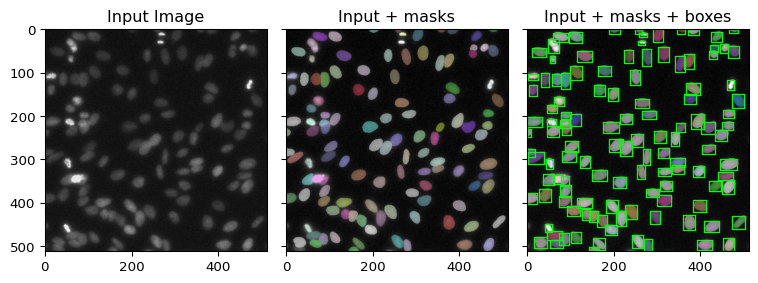

In [4]:
from stardist.data import test_image_nuclei_2d
from stardist.plot import render_label
from csbdeep.utils import normalize
import matplotlib.pyplot as plt

img = test_image_nuclei_2d()

# Labels: integer-valued array of same shape as 'img'. Each pixel is either 0 (bg) or >0 (unique object)
# raw_outputs: dict['coord', 'points', 'prob']. Each elem in the dict is the same length + correponds to a single unique object
# - dict['coord']:  The endpoints for each of the 32 radial vectors encompassing a single object
# - dict['points']: The center point for a single object
# - dict['prob']:   The probability that an object exists at this location
labels, raw_outputs = model.predict_instances(normalize(img))
bb = stardist_to_bbox(raw_outputs)
bb_plot = bb_list_to_bb_plot(bb, pos=[0,2,1,3], fc='none', ec='lime')

fig, ax = plt.subplots(1,3, sharey=True, layout='tight')

ax[0].imshow(img, cmap = 'gray')
ax[0].set_title('Input Image')

ax[1].imshow(render_label(labels, img=img))
ax[1].set_title("Input + masks")

ax[2].imshow(render_label(labels, img=img))
ax[2].add_collection(bb_plot)
ax[2].set_title("Input + masks + boxes")

fig.set_size_inches(8,3)

# 3D Example

In [99]:
from stardist.models import StarDist3D
model = StarDist3D.from_pretrained('3D_demo')

Found model '3D_demo' for 'StarDist3D'.
Loading network weights from 'weights_best.h5'.
Loading thresholds from 'thresholds.json'.
Using default values: prob_thresh=0.707933, nms_thresh=0.3.


In [126]:
def bb_filter(bb_in, ax, val):
    """
    bb :
        list of bboxes output from stardist_to_bbox()
    ax :
        The dimension being used for downstream visuzlization
    val :
        The slice index being visualized
    """
    bb_out = []
    for bb in bb_in:
        if ax == 0:
            if bb[0] <= val and bb[1] >= val:
                bb_out.append(bb)
        elif ax == 1:
            if bb[2] <= val and bb[3] >= val:
                bb_out.append(bb)
        elif ax == 2:
            if bb[4] <= val and bb[5] >= val:
                bb_out.append(bb)
        else:
            print('Invalid dimension idx supplied, expected {0,1,2}')

    return np.asarray(bb_out)

### Visualize middle slice of 3D test image

(31, 61, 57)


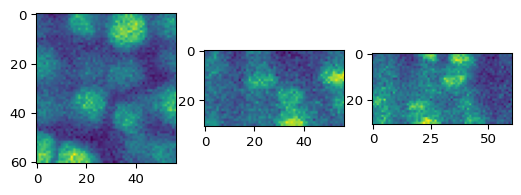

In [105]:
from stardist.data import test_image_nuclei_3d
img = test_image_nuclei_3d()
print(img.shape)

fig, ax = plt.subplots(1,3)
ax[0].imshow(img[img.shape[0]//2,:,:])
ax[1].imshow(img[:,img.shape[1]//2,:])
ax[2].imshow(img[:,:,img.shape[2]//2])

## Apply the pretrained 3D StarDist model + plot the results

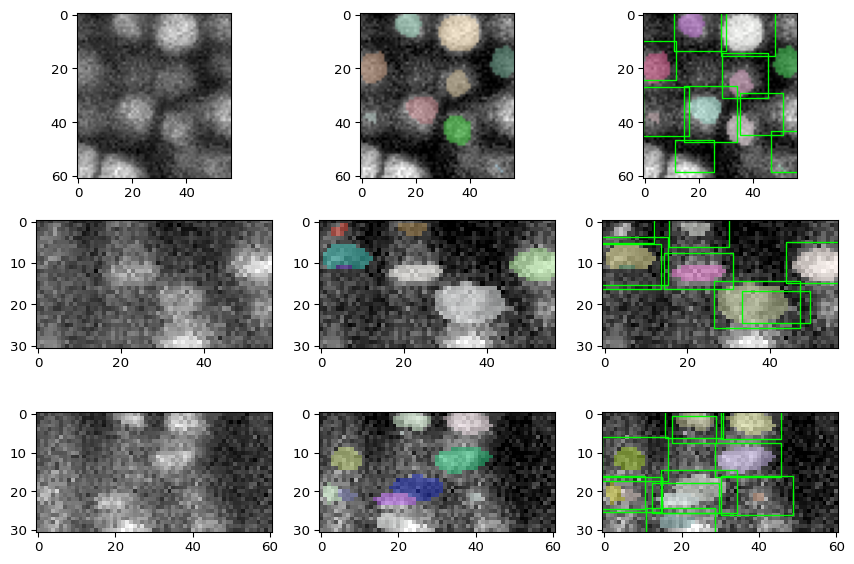

In [127]:
# raw_outputs[dist]: Nx96 array - dist[n] contains the lengths of the 96 radial vectors which define cell n
# raw_outputs[points]: Nx3 array - points[n] contains the xyz center voxel for cell n
# raw_outputs[prob]: N array - Contains the probability for each of the n cells
# raw_outputs[rays]: Custom object
# raw_outputs[rays_vertices] 96x3 array - rays_vertices[n] contains the endpoint for the nth radial vector, relative to the origin
# raw_outputs[rays_faces] 188x3 array - rays_faces[m] contains the indeces of 3 adjacent radial vectors. If a face were to be made between the 3 vectors in each elem, there would likely be a complete, closed surface

labels, raw_outputs = model.predict_instances(normalize(img))
bb = stardist_to_bbox(raw_outputs, mode='3D')

idx_ax0 = img.shape[0]//2
idx_ax1 = img.shape[1]//2
idx_ax2 = img.shape[2]//2

bb_plot0 = bb_list_to_bb_plot(bb_filter(bb, ax = 0, val = idx_ax0), pos=[2,4,3,5], fc='none', ec='lime')
bb_plot1 = bb_list_to_bb_plot(bb_filter(bb, ax = 1, val = idx_ax1), pos=[4,0,5,1], fc='none', ec='lime')
bb_plot2 = bb_list_to_bb_plot(bb_filter(bb, ax = 2, val = idx_ax2), pos=[2,0,3,1], fc='none', ec='lime')

fig, axs = plt.subplots(3,3,layout='tight')

sub_img = img[idx_ax0,:,:]
axs[0,0].imshow(sub_img, cmap='gray')
axs[0,1].imshow(render_label(labels[idx_ax0,:,:], img=sub_img))
axs[0,2].imshow(render_label(labels[idx_ax0,:,:], img=sub_img))
axs[0,2].add_collection(bb_plot0)

sub_img = img[:,idx_ax1,:]
axs[1,0].imshow(sub_img, cmap='gray')
axs[1,1].imshow(render_label(labels[:,idx_ax1,:], img=sub_img))
axs[1,2].imshow(render_label(labels[:,idx_ax1,:], img=sub_img))
axs[1,2].add_collection(bb_plot1)

sub_img = img[:,:,idx_ax2]
axs[2,0].imshow(sub_img, cmap='gray')
axs[2,1].imshow(render_label(labels[:,:,idx_ax2], img=sub_img))
axs[2,2].imshow(render_label(labels[:,:,idx_ax2], img=sub_img))
axs[2,2].add_collection(bb_plot2)

fig.set_size_inches(9,6)